In [514]:
import cv2
import numpy as np
import matplotlib.pyplot as plt


In [515]:
def display(img, camp='gray'):
    fig=plt.figure(figsize=(12,10))
    ax=fig.add_subplot(111)
    ax.imshow(img,cmap='gray')

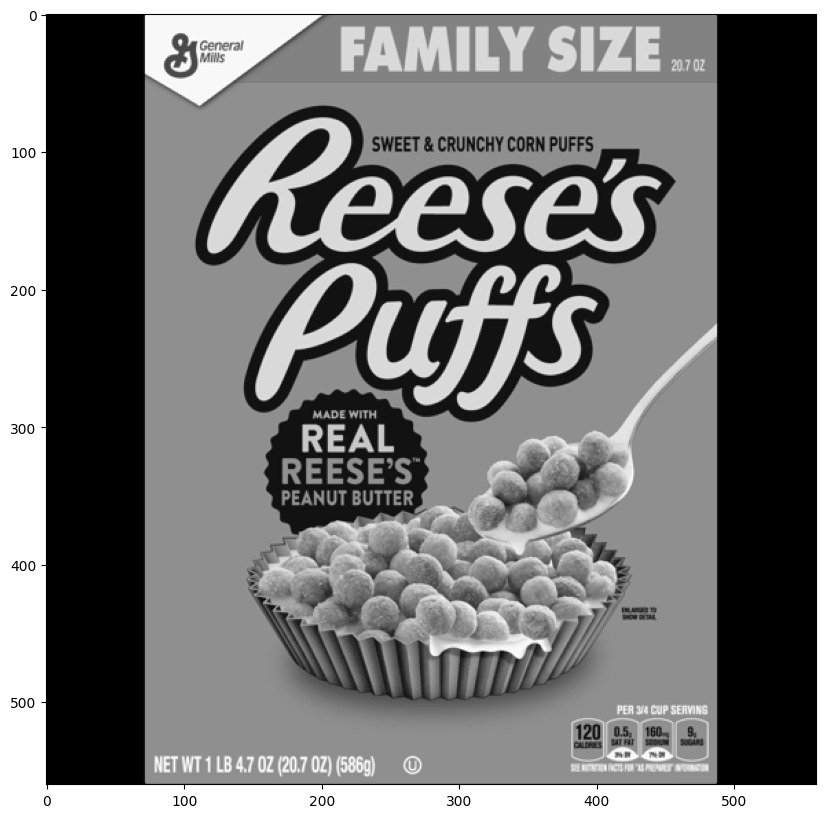

In [516]:
reeses=cv2.imread('../DATA/reeses_puffs.png',0)
display(reeses)

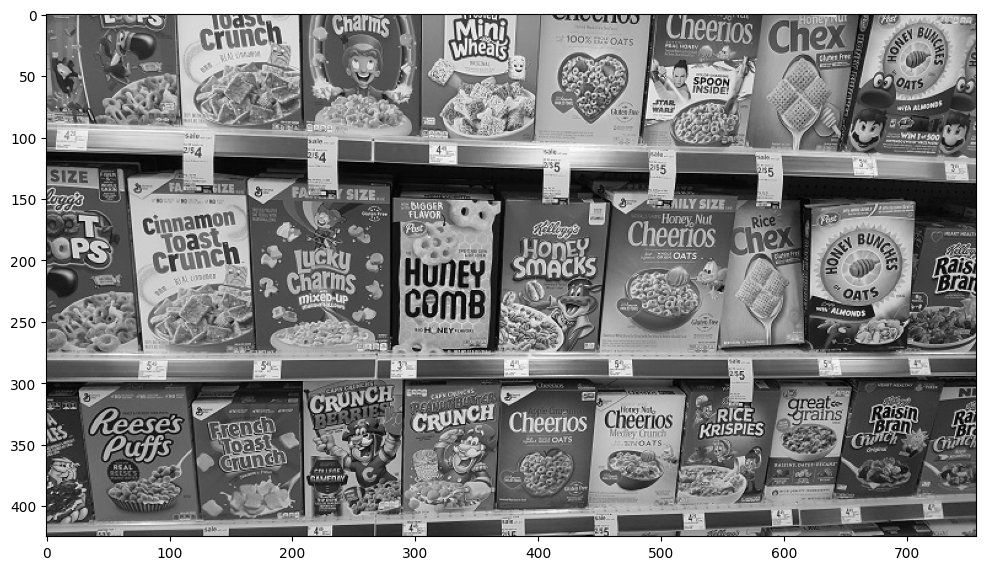

In [517]:
#target image
cereals=cv2.imread('../DATA/many_cereals.jpg',0)
display(cereals)

In [518]:
#Brute Force Detection with ARB descriptors
orb=cv2.ORB_create()

kp1,des1 = orb.detectAndCompute(reeses, None)
kp2,des2 = orb.detectAndCompute(cereals, None)


In [519]:
bf=cv2.BFMatcher(cv2.NORM_HAMMING,crossCheck=True)

In [520]:
matches=bf.match(des1,des2)

In [521]:
#slabše kot je ujemanje, večja bo distance
s_match=matches[0]
s_match.distance

56.0

In [522]:
len(matches)

139

In [523]:
# to je namesto for loop in bo rauporedila matches po razdalji (distance)
matches=sorted(matches,key=lambda x:x.distance)

In [524]:
# matches[:25] pomni da bo upoštevalo samo prvih 3 najboljši ujemanj
reeses_matches=cv2.drawMatches(reeses,kp1,cereals,kp2,matches[:3], None,flags=2) 

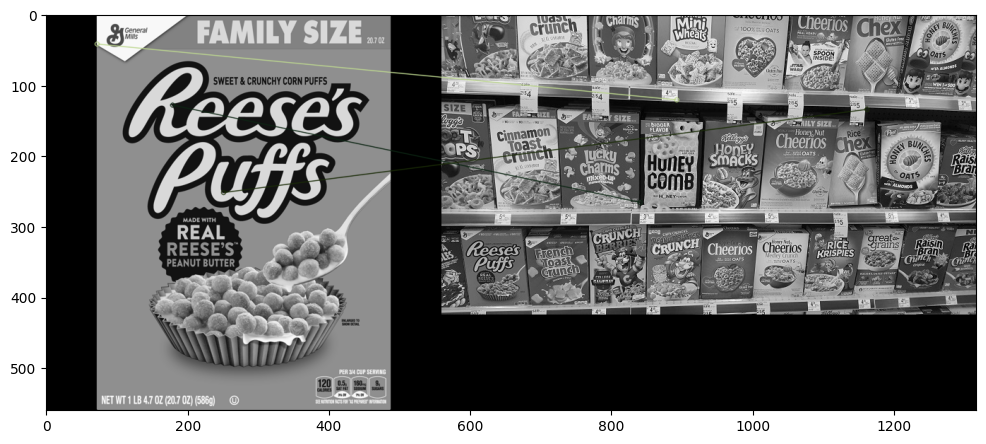

In [525]:
display(reeses_matches)

## Sif descriptors (Scale, Invariant Feature)
it perform well in a different scale of images

In [526]:
# create sift object
sift=cv2.xfeatures2d.SIFT_create()

In [527]:
kp1, des1= sift.detectAndCompute(reeses, None)
kp2, des2= sift.detectAndCompute(cereals, None)

In [528]:
des1

array([[19.,  0.,  0., ...,  1.,  0.,  0.],
       [15.,  0.,  0., ..., 11.,  1.,  0.],
       [21.,  0.,  0., ...,  0., 10., 13.],
       ...,
       [61.,  6.,  0., ...,  0.,  0.,  0.],
       [27.,  0.,  0., ...,  0.,  0.,  0.],
       [48.,  0.,  0., ...,  0.,  1.,  0.]], dtype=float32)

In [529]:
des2

array([[ 0.,  0.,  0., ...,  5.,  1.,  6.],
       [72., 41.,  0., ...,  6.,  0., 13.],
       [ 3.,  1.,  1., ...,  0.,  1., 17.],
       ...,
       [20.,  7., 35., ...,  0.,  0.,  0.],
       [ 4., 54., 81., ...,  0.,  0.,  0.],
       [32.,  2.,  5., ..., 35., 56., 25.]], dtype=float32)

In [530]:
#Calculate Matches
bf=cv2.BFMatcher()
# from descriptors and value K. K is number of bes matches
matches=bf.knnMatch(des1,des2,k=2)

In [531]:
matches

((< cv2.DMatch 000002447653B7B0>, < cv2.DMatch 0000024473997650>),
 (< cv2.DMatch 0000024475C27E70>, < cv2.DMatch 0000024475C07530>),
 (< cv2.DMatch 0000024475C07110>, < cv2.DMatch 0000024475C06E90>),
 (< cv2.DMatch 0000024475C07590>, < cv2.DMatch 0000024475C06E70>),
 (< cv2.DMatch 0000024475C070B0>, < cv2.DMatch 0000024475C07290>),
 (< cv2.DMatch 0000024475C07BD0>, < cv2.DMatch 0000024475C07610>),
 (< cv2.DMatch 0000024475C06D30>, < cv2.DMatch 0000024475C07350>),
 (< cv2.DMatch 0000024475C06E30>, < cv2.DMatch 0000024475C07410>),
 (< cv2.DMatch 0000024475C06EB0>, < cv2.DMatch 0000024475C070D0>),
 (< cv2.DMatch 0000024475C071B0>, < cv2.DMatch 0000024475C07F90>),
 (< cv2.DMatch 0000024475C07130>, < cv2.DMatch 0000024475C06E50>),
 (< cv2.DMatch 0000024475C073F0>, < cv2.DMatch 0000024475C073B0>),
 (< cv2.DMatch 0000024475C07E10>, < cv2.DMatch 0000024475C07230>),
 (< cv2.DMatch 0000024475C04530>, < cv2.DMatch 0000024475C045D0>),
 (< cv2.DMatch 0000024475C041F0>, < cv2.DMatch 0000024475C045F

In [532]:
good=[]

# less distance == metter match
# Ratio Match1 < 75% Match 2
for match1, match2 in matches:
    # IF match 1 distance is less than 75% of mathc 2 distance
    # THEN descriptro was a good mathc, lets keep it ! 
    if match1.distance < 0.75*match2.distance:
        good.append([match1])

In [533]:
len(good)

79

In [534]:
len(matches)

1501

In [535]:
good

[[< cv2.DMatch 000002447653B7B0>],
 [< cv2.DMatch 0000024475C04C90>],
 [< cv2.DMatch 0000024475C05250>],
 [< cv2.DMatch 0000024475C05290>],
 [< cv2.DMatch 0000024475C05490>],
 [< cv2.DMatch 0000024475C05A90>],
 [< cv2.DMatch 0000024475C05D90>],
 [< cv2.DMatch 0000024475C05F10>],
 [< cv2.DMatch 0000024475C06290>],
 [< cv2.DMatch 0000024475C064D0>],
 [< cv2.DMatch 0000024475C06890>],
 [< cv2.DMatch 0000024475C06990>],
 [< cv2.DMatch 00000244737BE5B0>],
 [< cv2.DMatch 00000244737BE5F0>],
 [< cv2.DMatch 00000244737BE6F0>],
 [< cv2.DMatch 00000244737BF470>],
 [< cv2.DMatch 00000244737BFDF0>],
 [< cv2.DMatch 00000244737BFEB0>],
 [< cv2.DMatch 00000244737BFF70>],
 [< cv2.DMatch 0000024475C00830>],
 [< cv2.DMatch 0000024475C00970>],
 [< cv2.DMatch 0000024475C01A70>],
 [< cv2.DMatch 0000024475C01BB0>],
 [< cv2.DMatch 0000024475C01BF0>],
 [< cv2.DMatch 0000024475C01DB0>],
 [< cv2.DMatch 0000024475C01DF0>],
 [< cv2.DMatch 0000024475C02FF0>],
 [< cv2.DMatch 0000024475C03170>],
 [< cv2.DMatch 00000

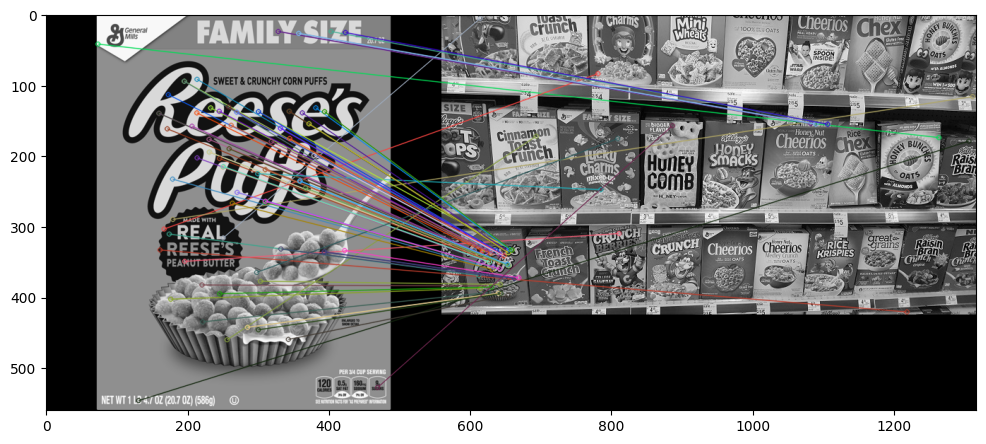

In [536]:
sift_matches=cv2.drawMatchesKnn(reeses,kp1,cereals,kp2,good,None,flags=2)
display(sift_matches)

## Land based matcher


In [537]:
sift=cv2.xfeatures2d.SIFT_create()

kp1, des1= sift.detectAndCompute(reeses, None)
kp2, des2= sift.detectAndCompute(cereals, None)

In [538]:
# FLANN parameters
FLANN_INDEX_DKTREE=0
index_params=dict(algorithm=FLANN_INDEX_DKTREE,trees=5)
search_params=dict(cheks=50)

flann=cv2.FlannBasedMatcher(index_params, search_params)

In [539]:
matches=flann.knnMatch(des1,des2,k=2)

In [540]:
matchesMask = [[0,0] for i in range(len(matches))]


In [541]:
for i,(match1, match2) in enumerate(matches):
    if match1.distance < 0.7*match2.distance:
        matchesMask[i]=[1,0]



In [542]:
draw_params=dict(matchColor=(0,255,0), singlePointColor=(255,0,0), matchesMask=matchesMask, flags=0)


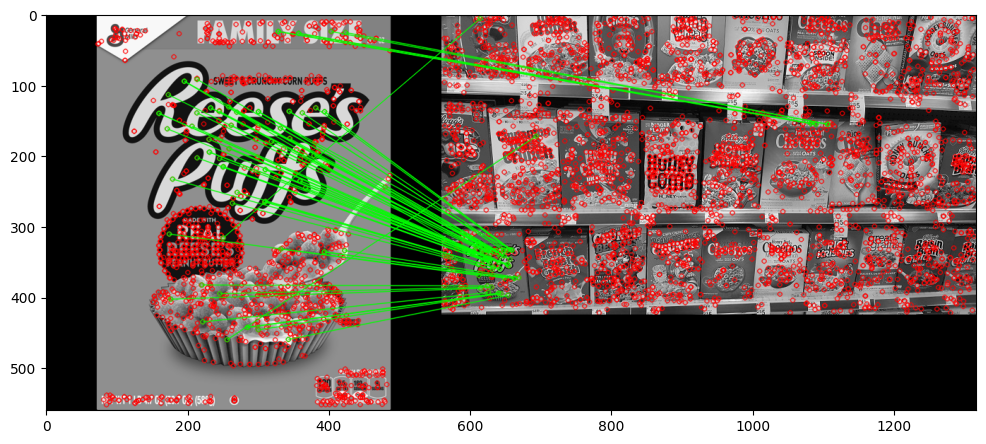

In [543]:
flann_matches=cv2.drawMatchesKnn(reeses,kp1,cereals,kp2,matches,None,**draw_params)
display(flann_matches)